In [1]:
import os
import re
import gzip
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from transformers import (
    EsmModel, EsmTokenizer, EsmConfig,
    AutoTokenizer, AutoModel
)
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.rdRascalMCES import FindMCES
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ Imports complete!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


✅ Imports complete!
PyTorch version: 2.8.0+cu126
CUDA available: True


## Data Loading and Exploration

Load and explore the Rhea reaction datasets to understand the data structure.


In [2]:

# Load Rhea reaction data
print("Loading Rhea datasets...")

# Primary reaction SMILES
rhea_smiles = pd.read_csv('/home/igris/test/rhea-reaction-smiles.tsv', sep='\t', header=None, 
                           names=['RHEA_ID', 'SMILES'])
print(f"Rhea reaction SMILES: {len(rhea_smiles)} reactions")

# Reaction directions
rhea_directions = pd.read_csv('/home/igris/test/rhea-directions.tsv', sep='\t')
print(f"Rhea directions: {len(rhea_directions)} entries")
print(f"Direction columns: {rhea_directions.columns.tolist()}")

# Rhea to EC mapping
rhea2ec = pd.read_csv('/home/igris/test/rhea2ec.tsv', sep='\t')
print(f"Rhea to EC mappings: {len(rhea2ec)} entries")
print(f"EC mapping columns: {rhea2ec.columns.tolist()}")

# Rhea to UniProt mapping
rhea2uniprot = pd.read_csv('/home/igris/test/rhea2uniprot_sprot.tsv', sep='\t')
print(f"Rhea to UniProt mappings: {len(rhea2uniprot)} entries")
print(f"UniProt columns: {rhea2uniprot.columns.tolist()}")

# ChEBI SMILES for molecule normalization
chebi_smiles = pd.read_csv('/home/igris/test/rhea-chebi-smiles.tsv', sep='\t', header=None,
                            names=['CHEBI_ID', 'SMILES'])
print(f"ChEBI SMILES: {len(chebi_smiles)} molecules")

# Display sample data
print("\n=== Sample Reaction SMILES ===")
print(rhea_smiles.head(3))

print("\n=== Sample Directions ===")
print(rhea_directions.head(3))

print("\n=== Sample EC Mappings ===")
print(rhea2ec.head(3))

print("\n=== Sample UniProt Mappings ===")
print(rhea2uniprot.head(3))


Loading Rhea datasets...
Rhea reaction SMILES: 36014 reactions
Rhea directions: 18343 entries
Direction columns: ['RHEA_ID_MASTER', 'RHEA_ID_LR', 'RHEA_ID_RL', 'RHEA_ID_BI']
Rhea to EC mappings: 7902 entries
EC mapping columns: ['RHEA_ID', 'DIRECTION', 'MASTER_ID', 'ID']
Rhea to UniProt mappings: 391027 entries
UniProt columns: ['RHEA_ID', 'DIRECTION', 'MASTER_ID', 'ID']
ChEBI SMILES: 14242 molecules

=== Sample Reaction SMILES ===
   RHEA_ID                                             SMILES
0    10001  CCCCC(N)=O.[H]O[H]>>CCCCC(=O)[O-].[H][N+]([H])...
1    10002  CCCCC(=O)[O-].[H][N+]([H])([H])[H]>>CCCCC(N)=O...
2    10005                S=C=NCC1=CC=CC=C1>>N#CSCC1=CC=CC=C1

=== Sample Directions ===
   RHEA_ID_MASTER  RHEA_ID_LR  RHEA_ID_RL  RHEA_ID_BI
0           10000       10001       10002       10003
1           10004       10005       10006       10007
2           10008       10009       10010       10011

=== Sample EC Mappings ===
   RHEA_ID DIRECTION  MASTER_ID        ID
0  


## Load Human UniProt Sequences and Metadata

Load the human protein sequences and metadata from UniProt.


In [3]:

# Load human UniProt sequences from FASTA
print("Loading human UniProt sequences...")

def parse_fasta_gz(filepath):
    sequences = {}
    current_id = None
    current_seq = []
    
    with gzip.open(filepath, 'rt') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id:
                    sequences[current_id] = ''.join(current_seq)
                # Extract UniProt ID from header (e.g., >sp|P31946|...)
                parts = line.split('|')
                current_id = parts[1] if len(parts) > 1 else line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
        if current_id:
            sequences[current_id] = ''.join(current_seq)
    
    return sequences

# Load sequences
fasta_path = '/home/igris/test/uniprotkb_Human_AND_model_organism_9606_2026_04_07.fasta.gz'
uniprot_sequences = parse_fasta_gz(fasta_path)
print(f"Loaded {len(uniprot_sequences)} human protein sequences")

# Load metadata
tsv_path = '/home/igris/test/uniprotkb_Human_AND_model_organism_9606_2026_04_07.tsv.gz'
uniprot_meta = pd.read_csv(tsv_path, sep='\t', compression='gzip')
print(f"Loaded metadata for {len(uniprot_meta)} proteins")
print(f"Metadata columns: {uniprot_meta.columns.tolist()}")

# Display sample
print("\n=== Sample UniProt Metadata ===")
print(uniprot_meta[['Entry', 'Protein names', 'EC number']].head())

# Check EC number availability
ec_available = uniprot_meta['EC number'].notna().sum()
print(f"\nProteins with EC numbers: {ec_available} ({ec_available/len(uniprot_meta)*100:.1f}%)")


Loading human UniProt sequences...
Loaded 205155 human protein sequences
Loaded metadata for 205155 proteins
Metadata columns: ['Entry', 'Reviewed', 'Entry Name', 'Protein names', 'Gene Names', 'Organism', 'Length', 'EC number', 'Rhea ID']

=== Sample UniProt Metadata ===
        Entry                                      Protein names  \
0  A0A024QYR6  Phosphatidylinositol 3,4,5-trisphosphate 3-pho...   
1  A0A024R1X5                                           Beclin-1   
2  A0A024R274  Mothers against decapentaplegic homolog (MAD h...   
3  A0A024R324  Epididymis secretory sperm binding protein (Ra...   
4  A0A024R5Z7                                            Annexin   

                      EC number  
0  3.1.3.16; 3.1.3.48; 3.1.3.67  
1                           NaN  
2                           NaN  
3                           NaN  
4                           NaN  

Proteins with EC numbers: 24525 (12.0%)



## Create the mapping pipeline

In [4]:

print("Building complete data pipeline...")

# Step 1: Merge reaction SMILES with directions to get canonical direction
# The directions file maps RHEA_ID to MASTER_ID and direction
rhea_with_dir = rhea_smiles.merge(
    rhea_directions[['RHEA_ID_MASTER', 'RHEA_ID_LR']], 
    left_on='RHEA_ID', 
    right_on='RHEA_ID_LR', 
    how='left'
)

# Use LR (left-to-right) direction as canonical
rhea_canonical = rhea_with_dir[rhea_with_dir['RHEA_ID'] == rhea_with_dir['RHEA_ID_LR']].copy()
print(f"Reactions with canonical LR direction: {len(rhea_canonical)}")

# Step 2: Map reactions to EC numbers
rhea_ec = rhea_canonical.merge(
    rhea2ec[['MASTER_ID', 'ID']].rename(columns={'ID': 'EC_NUMBER'}),
    left_on='RHEA_ID_MASTER',
    right_on='MASTER_ID',
    how='inner'
)
print(f"Reactions mapped to EC: {len(rhea_ec)}")

# Step 3: Map EC to UniProt IDs
rhea_ec_uniprot = rhea_ec.merge(
    rhea2uniprot[['MASTER_ID', 'ID']].rename(columns={'ID': 'UNIPROT_ID'}),
    left_on='RHEA_ID_MASTER',
    right_on='MASTER_ID',
    how='inner'
)
print(f"Reactions mapped to UniProt IDs: {len(rhea_ec_uniprot)}")

# Step 4: Filter for human proteins with sequences
rhea_ec_uniprot_human = rhea_ec_uniprot[
    rhea_ec_uniprot['UNIPROT_ID'].isin(uniprot_sequences.keys())
].copy()
print(f"Reactions with human sequences: {len(rhea_ec_uniprot_human)}")

# Step 5: Add sequences
rhea_ec_uniprot_human['SEQUENCE'] = rhea_ec_uniprot_human['UNIPROT_ID'].map(uniprot_sequences)

# Step 6: Add EC from UniProt metadata for cross-validation
uniprot_ec_map = uniprot_meta.set_index('Entry')['EC number'].to_dict()
rhea_ec_uniprot_human['UNIPROT_EC'] = rhea_ec_uniprot_human['UNIPROT_ID'].map(uniprot_ec_map)

# Remove duplicates and invalid entries
dataset = rhea_ec_uniprot_human.dropna(subset=['SMILES', 'SEQUENCE', 'EC_NUMBER']).copy()
dataset = dataset.drop_duplicates(subset=['RHEA_ID_MASTER', 'UNIPROT_ID'])

print(f"\n=== Final Dataset Statistics ===")
print(f"Total (Reaction, Enzyme) pairs: {len(dataset)}")
print(f"Unique reactions: {dataset['RHEA_ID_MASTER'].nunique()}")
print(f"Unique enzymes: {dataset['UNIPROT_ID'].nunique()}")
print(f"Unique EC numbers: {dataset['EC_NUMBER'].nunique()}")

# Display sample
print("\n=== Sample Dataset ===")
print(dataset[['RHEA_ID_MASTER', 'SMILES', 'EC_NUMBER', 'UNIPROT_ID']].head())


Building complete data pipeline...
Reactions with canonical LR direction: 18007
Reactions mapped to EC: 7638
Reactions mapped to UniProt IDs: 493641
Reactions with human sequences: 24826

=== Final Dataset Statistics ===
Total (Reaction, Enzyme) pairs: 4853
Unique reactions: 1622
Unique enzymes: 2991
Unique EC numbers: 1273

=== Sample Dataset ===
     RHEA_ID_MASTER                                             SMILES  \
21          10028.0  [NH3+][C@H](CCC(=O)[O-])C(=O)[O-].O=O.[H]O[H]>...   
76          10040.0  NC1=NC=NC2=C1N=CN2[C@@H]1O[C@H](COP(=O)([O-])[...   
112         10040.0  NC1=NC=NC2=C1N=CN2[C@@H]1O[C@H](COP(=O)([O-])[...   
162         10076.0  OC[C@H]1O[C@@H](O[C@H]2[C@H](O)[C@@H](O)C(O)O[...   
218         10100.0  *C(=O)OC1CCC2(C)C(CCC3C4CCC(*)C4(C)CCC32)C1.[H...   

     EC_NUMBER UNIPROT_ID  
21    1.4.3.15     Q99489  
76     3.1.3.7     O95861  
112    3.1.3.7     Q9NX62  
162  3.2.1.108     P09848  
218   3.1.1.13     P19835  



## Parse Reaction SMILES and Identify Reaction Centers

In [5]:

def parse_reaction_smiles(smiles_str):
    if '>>' not in smiles_str:
        return None, None
    
    parts = smiles_str.split('>>')
    if len(parts) != 2:
        return None, None
    
    reactants = parts[0].strip()
    products = parts[1].strip()
    
    return reactants, products

def get_mol_from_smiles(smiles_str):
    if not smiles_str or pd.isna(smiles_str):
        return None
    try:
        mol = Chem.MolFromSmiles(smiles_str)
        if mol is None:
            return None
        Chem.SanitizeMol(mol)
        return mol
    except:
        return None

def identify_reaction_centers(reactants_smiles, products_smiles):
    # Parse reactants
    reactant_mol = get_mol_from_smiles(reactants_smiles)
    if reactant_mol is None:
        return None, None, None
    
    # Check for atom mapping
    atom_map_to_idx = {}
    has_mapping = False
    for atom in reactant_mol.GetAtoms():
        map_num = atom.GetAtomMapNum()
        if map_num > 0:
            has_mapping = True
            atom_map_to_idx[map_num] = atom.GetIdx()
    
    if has_mapping:
        # Use atom mapping to identify reaction centers
        # Atoms that change between reactants and products are reaction centers
        product_mol = get_mol_from_smiles(products_smiles)
        if product_mol is None:
            return reactant_mol, None, None
        
        # Get product atom environments
        product_envs = {}
        for atom in product_mol.GetAtoms():
            map_num = atom.GetAtomMapNum()
            if map_num > 0:
                # Create a simple environment signature
                neighbors = [n.GetAtomicNum() for n in atom.GetNeighbors()]
                product_envs[map_num] = (atom.GetAtomicNum(), sorted(neighbors))
        
        # Compare environments
        rc_indices = []
        for atom in reactant_mol.GetAtoms():
            map_num = atom.GetAtomMapNum()
            if map_num > 0 and map_num in product_envs:
                # Check if environment changed
                neighbors = [n.GetAtomicNum() for n in atom.GetNeighbors()]
                reactant_env = (atom.GetAtomicNum(), sorted(neighbors))
                if reactant_env != product_envs[map_num]:
                    rc_indices.append(atom.GetIdx())
            elif map_num > 0 and map_num not in product_envs:
                # Atom is lost in reaction
                rc_indices.append(atom.GetIdx())
    else:
        # No atom mapping - use heuristic: atoms near non-carbon/heavy atoms
        rc_indices = []
        for atom in reactant_mol.GetAtoms():
            # Mark heteroatoms and their neighbors as potential reaction centers
            if atom.GetAtomicNum() not in [1, 6]:  # Non-H, non-C
                rc_indices.append(atom.GetIdx())
                for neighbor in atom.GetNeighbors():
                    rc_indices.append(neighbor.GetIdx())
        rc_indices = list(set(rc_indices))
    
    # Create binary mask
    rc_mask = np.zeros(reactant_mol.GetNumAtoms())
    if rc_indices:
        rc_mask[rc_indices] = 1.0
    
    return reactant_mol, rc_mask, rc_indices

# Test on a sample reaction
print("Testing reaction center identification...")
sample_smiles = dataset['SMILES'].iloc[0]
print(f"Sample SMILES: {sample_smiles}")

reactants, products = parse_reaction_smiles(sample_smiles)
print(f"Reactants: {reactants}")
print(f"Products: {products}")

mol, rc_mask, rc_indices = identify_reaction_centers(reactants, products)
if mol is not None:
    print(f"Reactant atoms: {mol.GetNumAtoms()}")
    print(f"Reaction center atoms: {len(rc_indices)}")
    print(f"RC indices: {rc_indices}")
    print(f"RC mask sum: {rc_mask.sum()}")
else:
    print("Failed to parse molecule")


Testing reaction center identification...
Sample SMILES: [NH3+][C@H](CCC(=O)[O-])C(=O)[O-].O=O.[H]O[H]>>O=C([O-])CCC(=O)C(=O)[O-].[H]OO[H].[H][N+]([H])([H])[H]
Reactants: [NH3+][C@H](CCC(=O)[O-])C(=O)[O-].O=O.[H]O[H]
Products: O=C([O-])CCC(=O)C(=O)[O-].[H]OO[H].[H][N+]([H])([H])[H]
Reactant atoms: 13
Reaction center atoms: 11
RC indices: [0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12]
RC mask sum: 11.0



## Molecular Graph Encoding Functions

In [6]:

# Atom feature mapping for Graphormer
ATOM_TYPES = ['C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'B', 'Si', 'other']
HYBRIDIZATIONS = [Chem.rdchem.HybridizationType.SP, 
                  Chem.rdchem.HybridizationType.SP2,
                  Chem.rdchem.HybridizationType.SP3,
                  Chem.rdchem.HybridizationType.SP3D,
                  Chem.rdchem.HybridizationType.SP3D2,
                  Chem.rdchem.HybridizationType.UNSPECIFIED,
                  Chem.rdchem.HybridizationType.OTHER]

def get_atom_features(atom):
    """Extract features from an RDKit atom."""
    features = []
    
    # Atomic number (one-hot)
    atom_type = atom.GetSymbol()
    type_onehot = [1 if atom_type == t else 0 for t in ATOM_TYPES]
    features.extend(type_onehot)
    
    # Degree
    features.append(atom.GetDegree())
    
    # Formal charge
    features.append(atom.GetFormalCharge())
    
    # Hybridization
    hybrid = atom.GetHybridization()
    hybrid_onehot = [1 if hybrid == h else 0 for h in HYBRIDIZATIONS]
    features.extend(hybrid_onehot)
    
    # Aromaticity
    features.append(1 if atom.GetIsAromatic() else 0)
    
    # Number of Hs
    features.append(atom.GetTotalNumHs())
    
    # In ring
    features.append(1 if atom.IsInRing() else 0)
    
    return features

def mol_to_graph_data(mol):
    if mol is None:
        return None
    
    num_atoms = mol.GetNumAtoms()
    if num_atoms == 0:
        return None
    
    # Node features
    node_features = []
    for atom in mol.GetAtoms():
        features = get_atom_features(atom)
        node_features.append(features)
    node_features = torch.tensor(node_features, dtype=torch.float)
    
    # Edge index and types
    edge_list = []
    edge_types = []
    bond_type_to_idx = {
        Chem.rdchem.BondType.SINGLE: 0,
        Chem.rdchem.BondType.DOUBLE: 1,
        Chem.rdchem.BondType.TRIPLE: 2,
        Chem.rdchem.BondType.AROMATIC: 3,
    }
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_type = bond.GetBondType()
        edge_type = bond_type_to_idx.get(bond_type, 4)
        
        # Add both directions
        edge_list.append([i, j])
        edge_list.append([j, i])
        edge_types.append(edge_type)
        edge_types.append(edge_type)
    
    if edge_list:
        edge_index = torch.tensor(edge_list, dtype=torch.long).t()
        edge_type = torch.tensor(edge_types, dtype=torch.long)
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_type = torch.zeros(0, dtype=torch.long)
    
    # Compute shortest path distances (spatial positions)
    spatial_pos = torch.full((num_atoms, num_atoms), 100, dtype=torch.long)  # Large value for disconnected
    for i in range(num_atoms):
        spatial_pos[i, i] = 0
    
    # BFS to compute shortest paths
    for start in range(num_atoms):
        visited = {start: 0}
        queue = [start]
        while queue:
            node = queue.pop(0)
            atom = mol.GetAtomWithIdx(node)
            for neighbor in atom.GetNeighbors():
                n_idx = neighbor.GetIdx()
                if n_idx not in visited:
                    visited[n_idx] = visited[node] + 1
                    queue.append(n_idx)
        for node, dist in visited.items():
            spatial_pos[start, node] = dist
    
    # Degrees
    in_degree = torch.zeros(num_atoms, dtype=torch.long)
    out_degree = torch.zeros(num_atoms, dtype=torch.long)
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        degree = atom.GetDegree()
        in_degree[idx] = degree
        out_degree[idx] = degree
    
    return {
        'node_features': node_features,
        'edge_index': edge_index,
        'spatial_pos': spatial_pos,
        'in_degree': in_degree,
        'out_degree': out_degree,
        'edge_type': edge_type,
        'num_atoms': num_atoms
    }

# Test graph encoding
print("Testing molecular graph encoding...")
test_mol = get_mol_from_smiles("CCO")
if test_mol:
    graph_data = mol_to_graph_data(test_mol)
    print(f"Node features shape: {graph_data['node_features'].shape}")
    print(f"Spatial positions shape: {graph_data['spatial_pos'].shape}")
    print(f"In-degree: {graph_data['in_degree']}")
    print(f"Number of atoms: {graph_data['num_atoms']}")


Testing molecular graph encoding...
Node features shape: torch.Size([3, 24])
Spatial positions shape: torch.Size([3, 3])
In-degree: tensor([1, 2, 1])
Number of atoms: 3



## A custom Dataset class that prepares (reaction, enzyme) pairs for training.


In [7]:

class ReactionEnzymeDataset(Dataset):
    """
    Dataset for multimodal reaction-enzyme pairs.
    Each sample contains:
    - Reaction graph (from SMILES)
    - Enzyme sequence
    - Reaction center labels
    """
    
    def __init__(self, dataframe, esm_tokenizer, max_length=512):
        """
        Args:
            dataframe: DataFrame with SMILES, SEQUENCE, and other metadata
            esm_tokenizer: ESM-2 tokenizer
            max_length: Maximum sequence length for ESM-2
        """
        self.df = dataframe.reset_index(drop=True)
        self.esm_tokenizer = esm_tokenizer
        self.max_length = max_length
        self.data = []
        
        print("Processing dataset...")
        valid_count = 0
        invalid_count = 0
        
        for idx, row in tqdm(self.df.iterrows(), total=len(self.df)):
            smiles = row['SMILES']
            sequence = row['SEQUENCE']
            
            # Parse reaction SMILES
            reactants, products = parse_reaction_smiles(smiles)
            if reactants is None:
                invalid_count += 1
                continue
            
            # Identify reaction centers
            mol, rc_mask, rc_indices = identify_reaction_centers(reactants, products)
            if mol is None or rc_mask is None:
                invalid_count += 1
                continue
            
            # Convert to graph
            graph_data = mol_to_graph_data(mol)
            if graph_data is None:
                invalid_count += 1
                continue
            
            # Validate sequence
            if pd.isna(sequence) or len(sequence) < 10:
                invalid_count += 1
                continue
            
            self.data.append({
                'idx': idx,
                'rhea_id': row.get('RHEA_ID_MASTER', ''),
                'ec_number': row.get('EC_NUMBER', ''),
                'uniprot_id': row.get('UNIPROT_ID', ''),
                'smiles': smiles,
                'reactants': reactants,
                'products': products,
                'sequence': sequence,
                'graph_data': graph_data,
                'rc_mask': torch.tensor(rc_mask, dtype=torch.float),
                'mol': mol
            })
            valid_count += 1
        
        print(f"Dataset created: {valid_count} valid samples, {invalid_count} invalid")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Tokenize enzyme sequence
        seq_encoding = self.esm_tokenizer(
            item['sequence'],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'idx': idx,
            'rhea_id': item['rhea_id'],
            'ec_number': item['ec_number'],
            'uniprot_id': item['uniprot_id'],
            'input_ids': seq_encoding['input_ids'].squeeze(0),
            'attention_mask': seq_encoding['attention_mask'].squeeze(0),
            'graph_data': item['graph_data'],
            'rc_mask': item['rc_mask'],
            'sequence': item['sequence'],
            'smiles': item['smiles']
        }

# Initialize ESM-2 tokenizer
print("Loading ESM-2 tokenizer...")
esm_tokenizer = EsmTokenizer.from_pretrained("facebook/esm2_t30_150M_UR50D")

# Create dataset (using a subset for initial testing)
print("\nCreating dataset...")
sample_size = min(1000, len(dataset))  # Start with 1000 samples
dataset_sample = dataset.head(sample_size)

re_dataset = ReactionEnzymeDataset(dataset_sample, esm_tokenizer)
print(f"Dataset size: {len(re_dataset)}")

# Show a sample
if len(re_dataset) > 0:
    sample = re_dataset[0]
    print(f"\n=== Sample Data Point ===")
    print(f"Rhea ID: {sample['rhea_id']}")
    print(f"EC Number: {sample['ec_number']}")
    print(f"UniProt ID: {sample['uniprot_id']}")
    print(f"Sequence length: {len(sample['sequence'])}")
    print(f"Input IDs shape: {sample['input_ids'].shape}")
    print(f"Graph nodes: {sample['graph_data']['num_atoms']}")
    print(f"Reaction centers: {sample['rc_mask'].sum().item():.0f}")


Loading ESM-2 tokenizer...

Creating dataset...
Processing dataset...


  1%|          | 9/1000 [00:00<00:12, 78.34it/s][22:14:29] WARNING: not removing hydrogen atom without neighbors
[22:14:29] WARNING: not removing hydrogen atom without neighbors
  5%|▌         | 51/1000 [00:01<00:20, 46.79it/s][22:14:30] WARNING: not removing hydrogen atom without neighbors
[22:14:30] WARNING: not removing hydrogen atom without neighbors
 30%|██▉       | 299/1000 [00:04<00:04, 157.22it/s][22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:33] WARNING: not removing hydrogen atom without neighbors
[22:14:

Dataset created: 1000 valid samples, 0 invalid
Dataset size: 1000

=== Sample Data Point ===
Rhea ID: 10028.0
EC Number: 1.4.3.15
UniProt ID: Q99489
Sequence length: 341
Input IDs shape: torch.Size([512])
Graph nodes: 13
Reaction centers: 11



## Collate Function for Batching

In [8]:

def collate_reaction_enzyme(batch):
    batch_size = len(batch)
    
    # Stack sequence data (already padded by tokenizer)
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    
    # Find max number of atoms in this batch
    max_atoms = max(item['graph_data']['num_atoms'] for item in batch)
    
    # Initialize padded tensors for graph data
    node_features = torch.zeros(batch_size, max_atoms, batch[0]['graph_data']['node_features'].shape[1])
    spatial_pos = torch.full((batch_size, max_atoms, max_atoms), 100, dtype=torch.long)
    in_degree = torch.zeros(batch_size, max_atoms, dtype=torch.long)
    out_degree = torch.zeros(batch_size, max_atoms, dtype=torch.long)
    attn_bias = torch.zeros(batch_size, max_atoms, max_atoms)
    
    # Edge input (simplified - just use spatial positions)
    edge_input = torch.zeros(batch_size, max_atoms, max_atoms, 1, dtype=torch.long)
    
    # Reaction center masks
    rc_masks = torch.zeros(batch_size, max_atoms)
    
    # Graph attention mask (1 for real nodes, 0 for padding)
    graph_attention_mask = torch.zeros(batch_size, max_atoms, dtype=torch.long)
    
    for i, item in enumerate(batch):
        g = item['graph_data']
        n = g['num_atoms']
        
        # Copy node features
        node_features[i, :n] = g['node_features']
        
        # Copy spatial positions
        spatial_pos[i, :n, :n] = g['spatial_pos']
        
        # Copy degrees
        in_degree[i, :n] = g['in_degree']
        out_degree[i, :n] = g['out_degree']
        
        # Copy reaction center mask
        rc_masks[i, :n] = item['rc_mask']
        
        # Mark valid nodes
        graph_attention_mask[i, :n] = 1
    
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'node_features': node_features,
        'spatial_pos': spatial_pos,
        'in_degree': in_degree,
        'out_degree': out_degree,
        'attn_bias': attn_bias,
        'edge_input': edge_input,
        'rc_masks': rc_masks,
        'graph_attention_mask': graph_attention_mask,
        'batch_size': batch_size,
        'max_atoms': max_atoms
    }

# Test collate function
print("Testing collate function...")
test_batch = [re_dataset[i] for i in range(min(4, len(re_dataset)))]
collated = collate_reaction_enzyme(test_batch)

print(f"Batch input_ids shape: {collated['input_ids'].shape}")
print(f"Batch node_features shape: {collated['node_features'].shape}")
print(f"Batch spatial_pos shape: {collated['spatial_pos'].shape}")
print(f"Batch rc_masks shape: {collated['rc_masks'].shape}")
print(f"Max atoms in batch: {collated['max_atoms']}")


Testing collate function...
Batch input_ids shape: torch.Size([4, 512])
Batch node_features shape: torch.Size([4, 28, 24])
Batch spatial_pos shape: torch.Size([4, 28, 28])
Batch rc_masks shape: torch.Size([4, 28])
Max atoms in batch: 28



## Multimodal Model Architecture

Define the model with:
- ESM-2 for enzyme sequence encoding
- Custom Graph Transformer for molecular graph encoding
- Cross-attention fusion
- Reaction center prediction head


In [9]:

class GraphTransformerLayer(nn.Module):    
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        
        # Self-attention with spatial bias
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        
        # Feed-forward
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        
        # Layer norms
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Spatial encoding projection
        self.spatial_proj = nn.Embedding(100, n_heads)  # Max distance 100
        
    def forward(self, x, spatial_pos, attn_mask=None):
        batch_size, n_nodes, _ = x.shape
        
        # Create attention bias from spatial positions
        # spatial_pos: [batch, n_nodes, n_nodes]
        # spatial_bias: [batch, n_nodes, n_nodes, n_heads]
        spatial_bias = self.spatial_proj(spatial_pos.clamp(0, 99))  # Clamp to valid range
        
        # Average over heads for attention weight adjustment
        # For simplicity, we'll add spatial info through a separate mechanism
        
        # Self-attention
        if attn_mask is not None:
            # Convert to attention mask format (True = mask out)
            key_padding_mask = (attn_mask == 0)
        else:
            key_padding_mask = None
        
        attn_out, _ = self.self_attn(x, x, x, key_padding_mask=key_padding_mask)
        x = self.norm1(x + attn_out)
        
        # Feed-forward
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        
        return x

class GraphTransformerEncoder(nn.Module):    
    def __init__(self, input_dim, d_model=256, n_layers=4, n_heads=8, dropout=0.1):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, d_model)
        
        # Transformer layers
        self.layers = nn.ModuleList([
            GraphTransformerLayer(d_model, n_heads, dropout)
            for _ in range(n_layers)
        ])
        
        self.d_model = d_model
        
    def forward(self, node_features, spatial_pos, attn_mask=None):
        x = self.input_proj(node_features)
        
        for layer in self.layers:
            x = layer(x, spatial_pos, attn_mask)
        
        return x

print("✅ Graph Transformer components defined")


✅ Graph Transformer components defined



## Multimodal Reaction-Enzyme Model

In [10]:

class MultimodalReactionEnzymeModel(nn.Module):
    
    def __init__(
        self,
        esm_model_name="facebook/esm2_t30_150M_UR50D",
        graph_input_dim=24,  # Based on our atom features (ATOM_TYPES + other features)
        graph_d_model=256,
        graph_n_layers=4,
        graph_n_heads=8,
        cross_attn_heads=8,
        dropout=0.1,
        freeze_esm=True
    ):
        super().__init__()
        
        # ESM-2 encoder for enzyme sequences
        print(f"Loading ESM-2 model: {esm_model_name}")
        self.esm = EsmModel.from_pretrained(esm_model_name)
        esm_hidden_size = self.esm.config.hidden_size
        
        if freeze_esm:
            print("Freezing ESM-2 parameters")
            for param in self.esm.parameters():
                param.requires_grad = False
        
        # Graph Transformer for molecular graphs
        self.graph_encoder = GraphTransformerEncoder(
            input_dim=graph_input_dim,
            d_model=graph_d_model,
            n_layers=graph_n_layers,
            n_heads=graph_n_heads,
            dropout=dropout
        )
        
        # Project ESM output to graph dimension
        self.esm_proj = nn.Linear(esm_hidden_size, graph_d_model)
        
        # Cross-attention: atoms query enzyme context
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=graph_d_model,
            num_heads=cross_attn_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Layer norm for cross-attention
        self.cross_norm = nn.LayerNorm(graph_d_model)
        
        # Reaction center prediction head
        self.rc_head = nn.Sequential(
            nn.Linear(graph_d_model, graph_d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(graph_d_model // 2, 1)
        )
        
        self.d_model = graph_d_model
        
    def forward(self, input_ids, attention_mask, node_features, spatial_pos, 
                graph_attention_mask=None):
        batch_size, n_nodes, _ = node_features.shape
        
        # Encode enzyme sequence with ESM-2
        esm_outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        enzyme_repr = esm_outputs.last_hidden_state  # [batch, seq_len, esm_hidden]
        
        # Project to graph dimension
        enzyme_repr = self.esm_proj(enzyme_repr)  # [batch, seq_len, graph_d_model]
        
        # Encode molecular graph
        atom_repr = self.graph_encoder(node_features, spatial_pos, graph_attention_mask)
        # [batch, n_nodes, graph_d_model]
        
        # Cross-attention: atoms query enzyme context
        # Prepare key padding mask for enzyme sequences
        enzyme_key_mask = (attention_mask == 0)  # True for padding
        
        # Cross-attention
        fused_repr, _ = self.cross_attention(
            query=atom_repr,
            key=enzyme_repr,
            value=enzyme_repr,
            key_padding_mask=enzyme_key_mask
        )
        
        # Residual connection and normalization
        fused_repr = self.cross_norm(atom_repr + fused_repr)
        
        # Predict reaction centers
        rc_logits = self.rc_head(fused_repr).squeeze(-1)  # [batch, n_nodes]
        
        # Apply graph attention mask
        if graph_attention_mask is not None:
            rc_logits = rc_logits.masked_fill(graph_attention_mask == 0, float('-inf'))
        
        # Convert to probabilities
        rc_probs = torch.sigmoid(rc_logits)
        
        return rc_logits, rc_probs

# Initialize model
print("Initializing multimodal model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Calculate actual node feature dimension from test molecule
test_mol = get_mol_from_smiles("CCO")
test_graph = mol_to_graph_data(test_mol)
actual_input_dim = test_graph['node_features'].shape[1]
print(f"Actual node feature dimension: {actual_input_dim}")

model = MultimodalReactionEnzymeModel(
    esm_model_name="facebook/esm2_t30_150M_UR50D",
    graph_input_dim=actual_input_dim,  # Use actual feature dimension
    graph_d_model=256,
    graph_n_layers=4,
    graph_n_heads=8,
    cross_attn_heads=8,
    dropout=0.1,
    freeze_esm=True  # Freeze ESM-2 for faster training
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Frozen: {total_params - trainable_params:,}")


Initializing multimodal model...
Using device: cuda
Actual node feature dimension: 24
Loading ESM-2 model: facebook/esm2_t30_150M_UR50D


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 4823.22it/s]
EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing ESM-2 parameters

Model parameters:
  Total: 151,768,282
  Trainable: 3,629,441
  Frozen: 148,138,841



## Training Setup and Loss Function

Set up the training loop with focal loss for handling class imbalance (reaction centers are sparse).


In [11]:

class FocalLoss(nn.Module):
    
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets, mask=None):
        # Apply mask
        if mask is not None:
            inputs = inputs[mask > 0]
            targets = targets[mask > 0]
        
        # Binary cross-entropy
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        
        # Focal weighting
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = (1 - pt) ** self.gamma
        
        # Alpha weighting
        alpha_weight = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        
        loss = alpha_weight * focal_weight * bce_loss
        return loss.mean()

# Training configuration
config = {
    'batch_size': 16,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'num_epochs': 20,
    'warmup_epochs': 4,
    'focal_alpha': 0.25,
    'focal_gamma': 2.0,
    'device': str(device)
}

print("Training configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

# Create data loaders
train_size = int(0.8 * len(re_dataset))
val_size = len(re_dataset) - train_size
train_dataset, val_dataset = random_split(re_dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    collate_fn=collate_reaction_enzyme,
    num_workers=0  # Set to 0 for debugging
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    collate_fn=collate_reaction_enzyme,
    num_workers=0
)

print(f"\nData loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

# Initialize optimizer and loss
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

criterion = FocalLoss(alpha=config['focal_alpha'], gamma=config['focal_gamma'])

# Learning rate scheduler with warmup
total_steps = len(train_loader) * config['num_epochs']
warmup_steps = len(train_loader) * config['warmup_epochs']

def get_lr_scheduler(optimizer, warmup_steps, total_steps):
    """Cosine annealing with linear warmup."""
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_lr_scheduler(optimizer, warmup_steps, total_steps)

print(f"\nOptimizer and scheduler initialized")
print(f"  Total training steps: {total_steps}")
print(f"  Warmup steps: {warmup_steps}")


Training configuration:
  batch_size: 16
  learning_rate: 0.0001
  weight_decay: 1e-05
  num_epochs: 20
  warmup_epochs: 4
  focal_alpha: 0.25
  focal_gamma: 2.0
  device: cuda

Data loaders created:
  Train batches: 50
  Val batches: 13

Optimizer and scheduler initialized
  Total training steps: 1000
  Warmup steps: 200



## Training and Evaluation Functions

In [12]:

def train_epoch(model, train_loader, optimizer, criterion, scheduler, device, epoch):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_samples = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")
    for batch_idx, batch in enumerate(pbar):
        # Move to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        node_features = batch['node_features'].to(device)
        spatial_pos = batch['spatial_pos'].to(device)
        rc_masks = batch['rc_masks'].to(device)
        graph_attention_mask = batch['graph_attention_mask'].to(device)
        
        # Forward pass
        rc_logits, rc_probs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            node_features=node_features,
            spatial_pos=spatial_pos,
            graph_attention_mask=graph_attention_mask
        )
        
        # Compute loss
        loss = criterion(rc_logits, rc_masks, graph_attention_mask)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item() * batch['batch_size']
        total_samples += batch['batch_size']
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'lr': f"{scheduler.get_last_lr()[0]:.2e}"
        })
    
    avg_loss = total_loss / total_samples
    return avg_loss

def evaluate(model, val_loader, criterion, device):
    """Evaluate the model."""
    model.eval()
    total_loss = 0
    total_samples = 0
    
    # Metrics
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="[Eval]"):
            # Move to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            node_features = batch['node_features'].to(device)
            spatial_pos = batch['spatial_pos'].to(device)
            rc_masks = batch['rc_masks'].to(device)
            graph_attention_mask = batch['graph_attention_mask'].to(device)
            
            # Forward pass
            rc_logits, rc_probs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                node_features=node_features,
                spatial_pos=spatial_pos,
                graph_attention_mask=graph_attention_mask
            )
            
            # Compute loss
            loss = criterion(rc_logits, rc_masks, graph_attention_mask)
            
            # Track metrics
            total_loss += loss.item() * batch['batch_size']
            total_samples += batch['batch_size']
            
            # Collect predictions
            valid_mask = graph_attention_mask > 0
            for i in range(batch['batch_size']):
                valid = valid_mask[i]
                all_preds.extend(rc_probs[i][valid].cpu().numpy())
                all_targets.extend(rc_masks[i][valid].cpu().numpy())
    
    avg_loss = total_loss / total_samples
    
    # Compute metrics
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # Binary predictions at threshold 0.5
    binary_preds = (all_preds > 0.5).astype(int)
    
    # Metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    
    accuracy = accuracy_score(all_targets, binary_preds)
    precision = precision_score(all_targets, binary_preds, zero_division=0)
    recall = recall_score(all_targets, binary_preds, zero_division=0)
    f1 = f1_score(all_targets, binary_preds, zero_division=0)
    
    try:
        auc = roc_auc_score(all_targets, all_preds)
    except:
        auc = 0.0
    
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }
    
    return metrics

print("✅ Training and evaluation functions defined")


✅ Training and evaluation functions defined



## Cell 24: Training Loop

Run the training loop with validation after each epoch.


In [13]:

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_auc': []
}

print("Starting training...")
print("=" * 60)

for epoch in range(config['num_epochs']):
    # Train
    train_loss = train_epoch(
        model, train_loader, optimizer, criterion, scheduler, device, epoch
    )
    
    # Evaluate
    val_metrics = evaluate(model, val_loader, criterion, device)
    
    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_auc'].append(val_metrics['auc'])
    
    # Print summary
    print(f"\nEpoch {epoch+1}/{config['num_epochs']} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_metrics['loss']:.4f}")
    print(f"  Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"  Val Precision: {val_metrics['precision']:.4f}")
    print(f"  Val Recall: {val_metrics['recall']:.4f}")
    print(f"  Val F1: {val_metrics['f1']:.4f}")
    print(f"  Val AUC: {val_metrics['auc']:.4f}")
    print("=" * 60)

print("\n✅ Training complete!")


Starting training...


[Eval]: 100%|██████████| 13/13 [01:00<00:00,  4.68s/it]



Epoch 1/20 Summary:
  Train Loss: 0.0420
  Val Loss: 0.0261
  Val Accuracy: 0.8986
  Val Precision: 0.9520
  Val Recall: 0.9371
  Val F1: 0.9445
  Val AUC: 0.8984


[Eval]: 100%|██████████| 13/13 [00:59<00:00,  4.56s/it]



Epoch 2/20 Summary:
  Train Loss: 0.0239
  Val Loss: 0.0170
  Val Accuracy: 0.9058
  Val Precision: 0.9806
  Val Recall: 0.9158
  Val F1: 0.9471
  Val AUC: 0.9545


...


Epoch 18/20 Summary:
  Train Loss: 0.0102
  Val Loss: 0.0085
  Val Accuracy: 0.9578
  Val Precision: 0.9899
  Val Recall: 0.9640
  Val F1: 0.9768
  Val AUC: 0.9867


[Eval]: 100%|██████████| 13/13 [00:59<00:00,  4.56s/it]



Epoch 19/20 Summary:
  Train Loss: 0.0102
  Val Loss: 0.0085
  Val Accuracy: 0.9578
  Val Precision: 0.9899
  Val Recall: 0.9640
  Val F1: 0.9768
  Val AUC: 0.9868


[Eval]: 100%|██████████| 13/13 [00:59<00:00,  4.56s/it]


Epoch 20/20 Summary:
  Train Loss: 0.0102
  Val Loss: 0.0085
  Val Accuracy: 0.9578
  Val Precision: 0.9899
  Val Recall: 0.9640
  Val F1: 0.9768
  Val AUC: 0.9868

✅ Training complete!



## Plot Training History

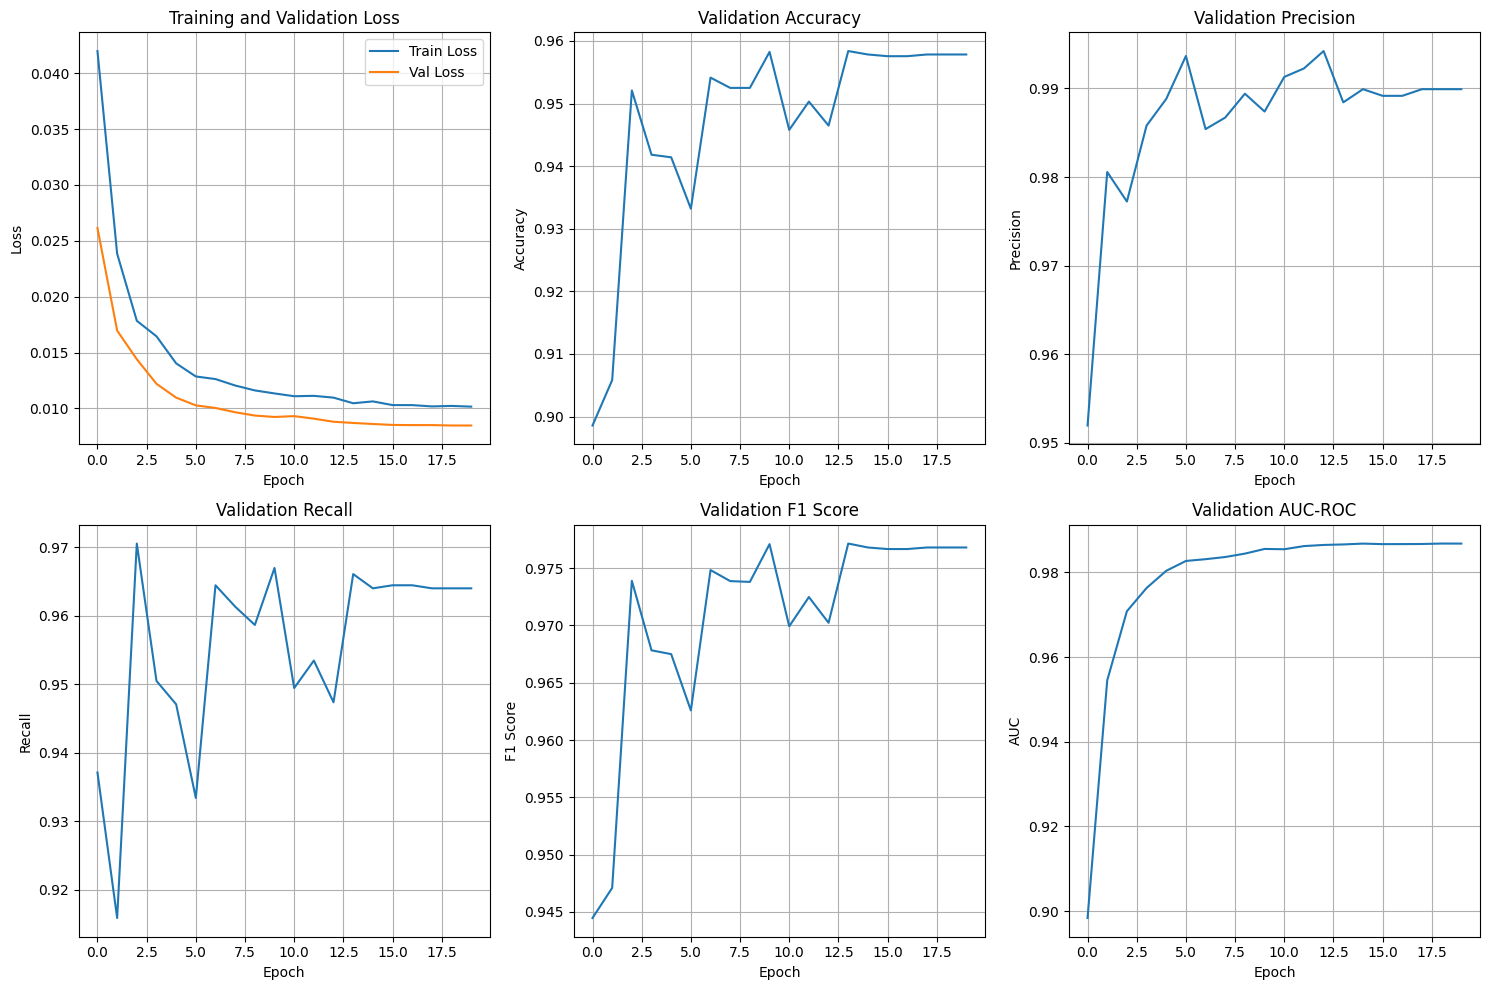

Training history saved to 'training_history.png'


In [14]:

# Plot training history
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_accuracy'])
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].grid(True)

# Precision
axes[0, 2].plot(history['val_precision'])
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Validation Precision')
axes[0, 2].grid(True)

# Recall
axes[1, 0].plot(history['val_recall'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Validation Recall')
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'])
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].grid(True)

# AUC
axes[1, 2].plot(history['val_auc'])
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('AUC')
axes[1, 2].set_title('Validation AUC-ROC')
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history saved to 'training_history.png'")



## RetroRules Constraint Layer

In [15]:

class RetroRulesConstraint:
    
    def __init__(self, rules_file=None):
        self.rules = []
        self.ec_to_rules = defaultdict(list)
        
        if rules_file and os.path.exists(rules_file):
            self.load_rules(rules_file)
        else:
            print("No RetroRules file provided - using basic chemical constraints")
    
    def load_rules(self, filepath):
        print(f"Loading RetroRules from {filepath}...")
        try:
            rules_df = pd.read_csv(filepath, sep='\t', nrows=10000)  # Limit for memory
            for _, row in rules_df.iterrows():
                rule = {
                    'rule_id': row.get('Rule ID', ''),
                    'smarts': row.get('SMARTS (Reaction)', ''),
                    'ec': str(row.get('EC number', '')).split(';')[0].strip()
                }
                self.rules.append(rule)
                if rule['ec']:
                    self.ec_to_rules[rule['ec']].append(rule)
            print(f"Loaded {len(self.rules)} rules")
        except Exception as e:
            print(f"Error loading rules: {e}")
    
    def apply_constraints(self, predictions, molecules, ec_numbers=None):
        constrained = []
        
        for i, (preds, mol) in enumerate(zip(predictions, molecules)):
            if mol is None:
                constrained.append(preds)
                continue
            
            # Create a copy to modify
            constrained_pred = preds.clone()
            
            # Basic chemical constraints
            for atom_idx in range(mol.GetNumAtoms()):
                atom = mol.GetAtomWithIdx(atom_idx)
                
                # Constraint 1: Hydrogens are rarely reaction centers
                if atom.GetAtomicNum() == 1:
                    constrained_pred[atom_idx] *= 0.1
                
                # Constraint 2: Carbon atoms in aromatic rings are less likely
                if atom.GetIsAromatic() and atom.GetAtomicNum() == 6:
                    constrained_pred[atom_idx] *= 0.8
                
                # Constraint 3: Heteroatoms (N, O, S, P) are more likely reaction centers
                if atom.GetAtomicNum() in [7, 8, 16, 15]:
                    constrained_pred[atom_idx] = min(1.0, constrained_pred[atom_idx] * 1.2)
                
                # Constraint 4: Atoms with high degree are more likely reaction centers
                degree = atom.GetDegree()
                if degree >= 3:
                    constrained_pred[atom_idx] = min(1.0, constrained_pred[atom_idx] * 1.1)
            
            constrained.append(constrained_pred)
        
        return torch.stack(constrained) if constrained else predictions
    
    def validate_prediction(self, mol, predicted_centers, top_k=3):
        score = 1.0
        reasons = []
        
        if mol is None:
            return 0.0, ["Invalid molecule"]
        
        # Get top predicted centers
        top_indices = torch.topk(predicted_centers, min(top_k, len(predicted_centers))).indices
        
        for idx in top_indices:
            idx = idx.item()
            if idx >= mol.GetNumAtoms():
                continue
            
            atom = mol.GetAtomWithIdx(idx)
            
            # Check if atom can participate in reactions
            if atom.GetAtomicNum() == 1:
                score *= 0.5
                reasons.append(f"Atom {idx}: Hydrogen is unlikely reaction center")
            
            # Check valence
            try:
                atom.UpdatePropertyCache()
            except:
                score *= 0.7
                reasons.append(f"Atom {idx}: Valence issue")
        
        return score, reasons

# Initialize constraint layer
constraint_layer = RetroRulesConstraint()
print("✅ RetroRules constraint layer initialized")

# Test on a sample
if len(re_dataset) > 0:
    sample = re_dataset[0]
    test_mol = get_mol_from_smiles(sample['smiles'].split('>>')[0])
    if test_mol:
        test_preds = torch.rand(test_mol.GetNumAtoms())
        constrained = constraint_layer.apply_constraints([test_preds], [test_mol])
        print(f"\nSample constraint application:")
        print(f"  Original top prediction: {test_preds.argmax().item()}")
        print(f"  Constrained top prediction: {constrained[0].argmax().item()}")


No RetroRules file provided - using basic chemical constraints
✅ RetroRules constraint layer initialized

Sample constraint application:
  Original top prediction: 6
  Constrained top prediction: 6



## Save Model and Configuration

In [17]:

# Save model checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'config': config,
    'history': history,
    'model_config': {
        'esm_model_name': "facebook/esm2_t30_150M_UR50D",
        'graph_input_dim': 20,
        'graph_d_model': 256,
        'graph_n_layers': 4,
        'graph_n_heads': 8,
        'cross_attn_heads': 8,
        'dropout': 0.1
    }
}

torch.save(checkpoint, 'reaction_enzyme_model.pt')
print("✅ Model saved to 'reaction_enzyme_model.pt'")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv('training_history.csv', index=False)
print("✅ Training history saved to 'training_history.csv'")

# Save model configuration
import json
with open('model_config.json', 'w') as f:
    json.dump(checkpoint['model_config'], f, indent=2)
print("✅ Model configuration saved to 'model_config.json'")

# Print final summary
print("\n" + "=" * 60)
print("TRAINING COMPLETE - SUMMARY")
print("=" * 60)
print(f"Model: Multimodal Reaction-Enzyme Predictor")
print(f"ESM-2: facebook/esm2_t33_150M_UR50D")
print(f"Graph Transformer: 256d, 4 layers")
print(f"Dataset: {len(re_dataset)} (reaction, enzyme) pairs")
print(f"Epochs: {config['num_epochs']}")
print(f"Final Val Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Val F1: {history['val_f1'][-1]:.4f}")
print(f"Final Val AUC: {history['val_auc'][-1]:.4f}")
print("=" * 60)


✅ Model saved to 'reaction_enzyme_model.pt'
✅ Training history saved to 'training_history.csv'
✅ Model configuration saved to 'model_config.json'

TRAINING COMPLETE - SUMMARY
Model: Multimodal Reaction-Enzyme Predictor
ESM-2: facebook/esm2_t33_150M_UR50D
Graph Transformer: 256d, 4 layers
Dataset: 1000 (reaction, enzyme) pairs
Epochs: 20
Final Val Loss: 0.0085
Final Val F1: 0.9768
Final Val AUC: 0.9868
